In [1]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'experiments' / 'utils').exists()), None)
if project_root is None:
    raise RuntimeError('Project root not found from current working directory.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import round_metrics_with_ci_table, summarize_metrics_with_ci

In [2]:
from cycler import cycler
#line_cycler   = (cycler(color=["#FF2525", "#90C4FF", "#009E73", "#0072B2", "#D55E00",  "#F0E442", "#E69F00"]) +
#                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))
line_cycler   = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))

marker_cycler = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["none", "none", "none", "none", "none", "none", "none"]) +
                 cycler(marker=["4", "2", "3", "1", "+", "x", "."]))

# Attack-forg-ep

We attack the model with the >3 mem-sample setand 100 token prefix length


In [3]:
expath = '../experiments/attack_forg_ep/'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_ep.parquet'))
df.head()

,prefix_250,prefix_200,prefix_150,prefix_100,suffix,3b_ep0,3b_ep0_em,3b_ep0_bleu,3b_ep0_meteor,3b_ep0_rougeL,...,15b_ep2,15b_ep2_em,15b_ep2_bleu,15b_ep2_meteor,15b_ep2_rougeL,15b_ep3,15b_ep3_em,15b_ep3_bleu,15b_ep3_meteor,15b_ep3_rougeL
0,NotNullAndAfterIsNull() {\n persistence...,null);\n assertThat(events).hasSize(1)...,AuditEventRepository.save(testUserEvent);\n ...,"2);\n assertThat(events).extracting(""pr...",);\n\n PersistentAuditEvent testUserOth...,);\n\n List<PersistenceAuditEvent> even...,0.0,6.345259,0.363941,0.068966,...,);\n\n List<PersistenceAuditEvent> even...,0.0,21.066552,0.281124,0.142857,);\n\n List<PersistenceAuditEvent> even...,0.0,10.774132,0.301205,0.068966
1,;\n public static final int[] FontFamil...,"0300dc, 0x7f0300dd, 0x7f0300de };\n pub...",_fontProviderCerts = 1;\n public static...,Package = 4;\n public static final int ...,"x7f0300df, 0x7f0300e0, 0x7f0300e1, 0x7f030208 ...","x7f0300d8, 0x7f0300d9, 0x7f0300da, 0x7f0300db,...",0.0,4.023186,0.119048,0.000000,...,x7f0300d8 };\n public static final int ...,0.0,14.291174,0.417652,0.266667,x7f0300d8 };\n public static final int ...,0.0,14.291174,0.417652,0.266667
2,"ent, trademark, and\n * attribution ...","(d) If the Work includes a ""NOTICE"" text file...","NOTICE file, excluding those notices that do ...",ivative Works; within the Source form or\n * ...,alongside\n * or as an addendum to ...,alongside\n * or as an addendum to ...,0.0,97.257663,0.997366,0.983607,...,alongside\n * or as an addendum to ...,0.0,35.685138,0.454046,0.400000,alongside\n * or as an addendum to ...,0.0,35.180932,0.499759,0.419355
3,}\n setSystemInformation(recordType);\...,(getPrimaryKey() == null) {\n this...,@JsonIgnore\n public String getLoggedInUse...,JsonIgnore\n public void setSystemInformati...,Status(activeStatus);\n }\n\n @JsonIgnor...,Status(activeStatus);\n }\n\n @JsonIgnor...,0.0,29.203174,0.471799,0.400000,...,Status(activeStatus);\n }\n\n @JsonIgnor...,0.0,28.128435,0.394185,0.444444,Status(activeStatus);\n }\n\n @JsonIgnor...,0.0,34.345031,0.452791,0.588235
4,SIZE} if size is 0.</li>\n * <li>{...,10#CL_MEM_USE_HOST_PTR MEM_USE_HOST_PTR} or {@...,{@code host_ptr} is not {@code NULL} but\n ...,USE_HOST_PTR MEM_USE_HOST_PTR} are not set in ...,OpenCL implementation on the device.</li>\n ...,OpenCL implementation on the device.</li>\n ...,1.0,100.000000,0.999985,1.000000,...,OpenCL implementation for buffer object.</li>...,0.0,32.696253,0.521511,0.321429,OpenCL implementation for\n * buf...,0.0,84.372928,0.814421,0.827586


## StarCoder2-3b

In [4]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_3b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'3b_{ep}_{metric}',
)
ep_3b_absolute = ep_3b_absolute_ci[metrics].copy()
ep_3b_absolute_ci = round_metrics_with_ci_table(ep_3b_absolute_ci, decimals=3)
ep_3b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.389,"[0.359, 0.42]",65.251,"[63.024, 67.452]",0.707,"[0.687, 0.727]",0.682,"[0.662, 0.703]"
ep1,0.087,"[0.071, 0.106]",44.873,"[42.881, 46.924]",0.551,"[0.532, 0.569]",0.517,"[0.497, 0.536]"
ep2,0.108,"[0.09, 0.129]",45.210,"[43.133, 47.22]",0.552,"[0.533, 0.571]",0.518,"[0.499, 0.538]"
ep3,0.105,"[0.087, 0.126]",44.754,"[42.755, 46.755]",0.551,"[0.533, 0.57]",0.514,"[0.495, 0.533]"


In [5]:
# With the baseline
first = ep_3b_absolute.iloc[0]

ep_3b_baseline = ep_3b_absolute.subtract(first)
ep_3b_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,-0.302,-20.378136,-0.155496,-0.165557
ep2,-0.281,-20.041369,-0.154594,-0.164421
ep3,-0.284,-20.497473,-0.155272,-0.168451


## StarCoder2-7b 

In [6]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_7b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'7b_{ep}_{metric}',
)
ep_7b_absolute = ep_7b_absolute_ci[metrics].copy()
ep_7b_absolute_ci = round_metrics_with_ci_table(ep_7b_absolute_ci, decimals=3)
ep_7b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.395,"[0.365, 0.426]",66.351,"[64.163, 68.524]",0.720,"[0.7, 0.74]",0.694,"[0.674, 0.715]"
ep1,0.015,"[0.009, 0.025]",38.141,"[36.406, 39.915]",0.525,"[0.507, 0.542]",0.483,"[0.465, 0.502]"
ep2,0.110,"[0.092, 0.131]",46.088,"[44.059, 48.118]",0.566,"[0.548, 0.585]",0.527,"[0.508, 0.547]"
ep3,0.116,"[0.098, 0.137]",46.953,"[44.955, 48.982]",0.572,"[0.554, 0.59]",0.534,"[0.514, 0.553]"


In [7]:
# With the baseline
first = ep_7b_absolute.iloc[0]

ep_7b_baseline = ep_7b_absolute.subtract(first)
ep_7b_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,-0.380,-28.209514,-0.194855,-0.210841
ep2,-0.285,-20.262414,-0.153614,-0.166676
ep3,-0.279,-19.397761,-0.147621,-0.160333


## StarCoder2-15b

In [8]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_15b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'15b_{ep}_{metric}',
)
ep_15b_absolute = ep_15b_absolute_ci[metrics].copy()
ep_15b_absolute_ci = round_metrics_with_ci_table(ep_15b_absolute_ci, decimals=3)
ep_15b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.455,"[0.424, 0.486]",71.477,"[69.353, 73.563]",0.759,"[0.741, 0.778]",0.739,"[0.719, 0.758]"
ep1,0.145,"[0.125, 0.168]",52.553,"[50.504, 54.636]",0.613,"[0.595, 0.632]",0.583,"[0.563, 0.603]"
ep2,0.143,"[0.123, 0.166]",53.086,"[51.041, 55.093]",0.619,"[0.6, 0.637]",0.586,"[0.566, 0.605]"
ep3,0.155,"[0.134, 0.179]",54.477,"[52.407, 56.502]",0.629,"[0.611, 0.648]",0.596,"[0.577, 0.615]"


In [9]:
# With the baseline
first = ep_15b_absolute.iloc[0]

ep_15b_baseline = ep_15b_absolute.subtract(first)
ep_15b_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,-0.310,-18.923325,-0.146002,-0.155347
ep2,-0.312,-18.390635,-0.140553,-0.152894
ep3,-0.300,-17.000262,-0.130486,-0.142932


## Visuals

In [10]:
df_ep_mem_plot = pd.DataFrame({'3B': ep_3b_absolute['em'], '7B': ep_7b_absolute['em'], '15B': ep_15b_absolute['em']})
df_ep_mem_plot

,3B,7B,15B
ep0,0.389,0.395,0.455
ep1,0.087,0.015,0.145
ep2,0.108,0.110,0.143
ep3,0.105,0.116,0.155


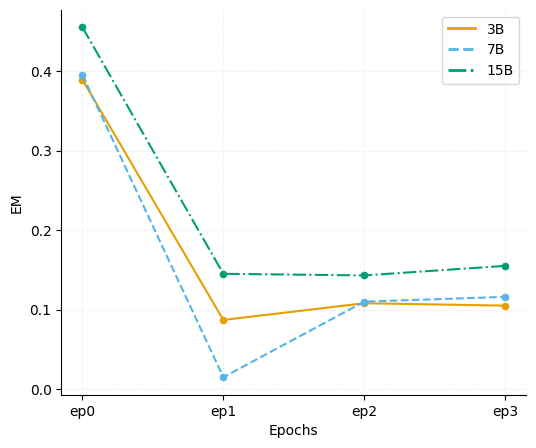

In [11]:
from matplotlib.lines import Line2D

legend_elements = [Line2D([0], [0], lw=2, label='3B', color='#E69F00', linestyle='-'),
                   Line2D([0], [0], lw=2, label='7B', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='15B', color='#009E73', linestyle='-.')]

fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['3B', '7B', '15B']
colors = ['#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', '--', '-.']
markers = ['o', 'o', 'o']

for i, label in enumerate(labels):
    # Line with matching color and linestyle
    ax.plot(df_ep_mem_plot.index, df_ep_mem_plot[label], 
            label=label, 
            color=colors[i], 
            linestyle=linestyles[i],
            marker=markers[i], 
            markeredgewidth=0.5, 
            markersize=5) 

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Epochs')
ax.set_ylabel('EM')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='--')

plt.show()
fig.savefig('./attack_forget_ep.pdf', format='pdf')

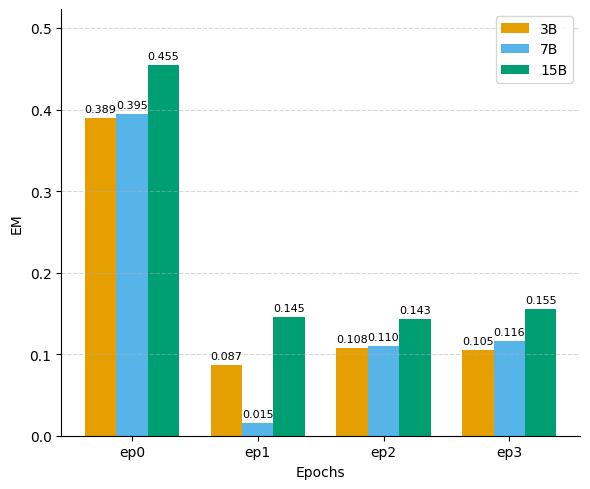

In [12]:
from matplotlib.patches import Patch
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

# Convert to bar plot
labels = ['3B', '7B', '15B']
colors = ['#E69F00', '#56B4E9', '#009E73']
x = np.arange(len(df_ep_mem_plot.index))  # Epoch positions
width = 0.25  # Width of bars

# Create bars for each model size
for i, (label, color) in enumerate(zip(labels, colors)):
    bars = ax.bar(x + i*width, df_ep_mem_plot[label], width, label=label, color=color)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Epochs')
ax.set_ylabel('EM')
ax.set_xticks(x + width)  # Center the tick labels
ax.set_xticklabels(df_ep_mem_plot.index)

# Adjust y-limit to accommodate labels
max_val = df_ep_mem_plot.max().max()
ax.set_ylim(0, max_val * 1.15)

# Create legend with rectangular patches
legend_elements = [Patch(facecolor='#E69F00', label='3B'),
                   Patch(facecolor='#56B4E9', label='7B'),
                   Patch(facecolor='#009E73', label='15B')]

plt.legend(handles=legend_elements, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
fig.savefig('./bar-attack_forget_ep.pdf', format='pdf')

In [13]:
forge_ep0 = df_ep_mem_plot.T['ep0']
forge_ep3 = df_ep_mem_plot.T['ep3']
forge_ep3

3B     0.105
7B     0.116
15B    0.155
Name: ep3, dtype: float64

In [14]:
df_ep_mem_plot.T

,ep0,ep1,ep2,ep3
3B,0.389,0.087,0.108,0.105
7B,0.395,0.015,0.110,0.116
15B,0.455,0.145,0.143,0.155


In [15]:
df_ep_mem_plot.T

,ep0,ep1,ep2,ep3
3B,0.389,0.087,0.108,0.105
7B,0.395,0.015,0.110,0.116
15B,0.455,0.145,0.143,0.155


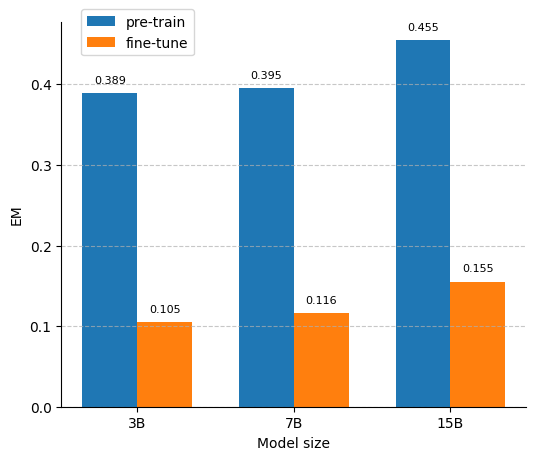

In [16]:
#"#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"
ep0 = df_ep_mem_plot.T['ep0'] 
ep3 = df_ep_mem_plot.T['ep3']

indices = range(len(ep0))
names = df_ep_mem_plot.T.index

# Calculate optimal width
width = 0.35  # Adjusted to be constant and easy to manage

fig, ax = plt.subplots(figsize=(6, 5))
plt.rc("axes", prop_cycle=line_cycler)


# Plot bars
bar1 = ax.bar(np.array(indices) - width/2, ep0, width, label='pre-train')
bar2 = ax.bar(np.array(indices) + width/2, ep3, width,  label='fine-tune')

# Add value labels on top of bars
for i, (b1, b2) in enumerate(zip(bar1, bar2)):
    height1 = b1.get_height()
    height2 = b2.get_height()
    
    # Add text labels showing exact EM scores
    ax.text(b1.get_x() + b1.get_width()/2., height1 + 0.01,
            f'{height1:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(b2.get_x() + b2.get_width()/2., height2 + 0.01,
            f'{height2:.3f}', ha='center', va='bottom', fontsize=8)

# Set the x-ticks and x-tick labels
ax.set_xticks(indices)
ax.set_xticklabels(names)

# Add labels and title
ax.set_xlabel('Model size')
ax.set_ylabel('EM')
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.legend(loc='upper right', bbox_to_anchor=(0.3, 1.05), ncol=1)
ax.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()
fig.savefig('./attack_forget_msize.pdf', format='pdf')

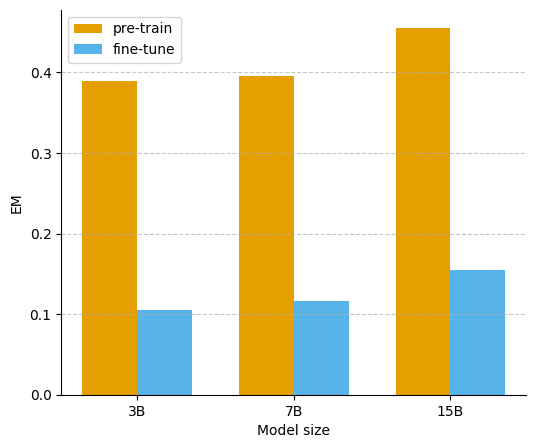

In [17]:
#"#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"
ep0 = df_ep_mem_plot.T['ep0']
ep3 = df_ep_mem_plot.T['ep3']

indices = range(len(ep0))
names = df_ep_mem_plot.T.index

# Calculate optimal width
width = 0.35  # Adjusted to be constant and easy to manage

fig, ax = plt.subplots(figsize=(6, 5))
plt.rc("axes", prop_cycle=line_cycler)


# Plot bars
bar1 = ax.bar(np.array(indices) - width/2, ep0, width, label='pre-train')
bar2 = ax.bar(np.array(indices) + width/2, ep3, width,  label='fine-tune')

# Set the x-ticks and x-tick labels
ax.set_xticks(indices)
ax.set_xticklabels(names)

# Add labels and title
ax.set_xlabel('Model size')
ax.set_ylabel('EM')
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
ax.legend()

plt.show()
fig.savefig('./old-attack_forget_msize.pdf', format='pdf')

In [18]:
df_ep_mem_baseline = pd.DataFrame({'3b': ep_3b_baseline['em'], '7b': ep_7b_baseline['em'], '15b': ep_15b_baseline['em']})
df_ep_mem_baseline

,3b,7b,15b
ep0,0.000,0.000,0.000
ep1,-0.302,-0.380,-0.310
ep2,-0.281,-0.285,-0.312
ep3,-0.284,-0.279,-0.300


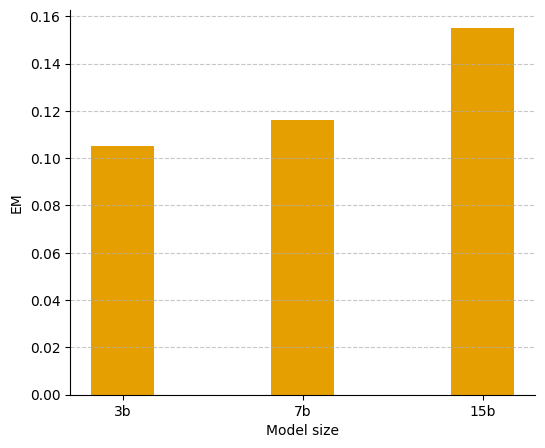

In [19]:
#"#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"
ep3 = df_ep_mem_plot.T['ep3']



indices = range(len(ep0))
names = df_ep_mem_baseline.T.index

# Calculate optimal width
width = 0.35  # Adjusted to be constant and easy to manage

fig, ax = plt.subplots(figsize=(6, 5))
plt.rc("axes", prop_cycle=line_cycler)


# Plot bars
bar1 = ax.bar(indices, ep3, width)
#bar2 = ax.bar(np.array(indices) + width/2, ep3, width,  label='fine-tune')

# Set the x-ticks and x-tick labels
ax.set_xticks(indices)
ax.set_xticklabels(names)

# Add labels and title
ax.set_xlabel('Model size')
ax.set_ylabel('EM')
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
#ax.legend()

plt.show()

# Attack-mem-plen

We attack the model:
- trained on 3 epochs
- dedup rate >3

We vary the prefix length

In [41]:
expath = '../experiments/attack_forg_plen/'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_plen.parquet'))
df.head()

,prefix_250,prefix_200,prefix_150,prefix_100,suffix,3b_ep0_p100,3b_ep0_p150,3b_ep0_p200,3b_ep0_p250,3b_ep0_p100_em,...,15b_ep3_p150_meteor,15b_ep3_p150_rougeL,15b_ep3_p200_em,15b_ep3_p200_bleu,15b_ep3_p200_meteor,15b_ep3_p200_rougeL,15b_ep3_p250_em,15b_ep3_p250_bleu,15b_ep3_p250_meteor,15b_ep3_p250_rougeL
0,NotNullAndAfterIsNull() {\n persistence...,null);\n assertThat(events).hasSize(1)...,AuditEventRepository.save(testUserEvent);\n ...,"2);\n assertThat(events).extracting(""pr...",);\n\n PersistentAuditEvent testUserOth...,);\n\n List<PersistenceAuditEvent> even...,);\n\n List<AuditEvent> events = custom...,);\n\n List<AuditEvent> events = custom...,);\n\n List<AuditEvent> events = custom...,0.0,...,0.346390,0.129032,0.0,9.078154,0.292969,0.064516,0.0,9.078154,0.292969,0.064516
1,;\n public static final int[] FontFamil...,"0300dc, 0x7f0300dd, 0x7f0300de };\n pub...",_fontProviderCerts = 1;\n public static...,Package = 4;\n public static final int ...,"x7f0300df, 0x7f0300e0, 0x7f0300e1, 0x7f030208 ...","x7f0300d8, 0x7f0300d9, 0x7f0300da, 0x7f0300db,...","x7f0300d8, 0x7f0300d9, 0x7f0300da, 0x7f0300db,...","x7f0300d8, 0x7f0300d9, 0x7f0300da, 0x7f0300db,...",x7f0300d8 };\n public static final int ...,0.0,...,0.417652,0.266667,0.0,18.496911,0.498110,0.320000,0.0,14.291174,0.417652,0.266667
2,"ent, trademark, and\n * attribution ...","(d) If the Work includes a ""NOTICE"" text file...","NOTICE file, excluding those notices that do ...",ivative Works; within the Source form or\n * ...,alongside\n * or as an addendum to ...,alongside\n * or as an addendum to ...,alongside\n * or as an addendum to ...,alongside\n * or as an addendum to ...,alongside\n * or as an addendum to ...,0.0,...,0.391579,0.372881,0.0,35.271867,0.438360,0.385965,0.0,27.794408,0.349787,0.360656
3,}\n setSystemInformation(recordType);\...,(getPrimaryKey() == null) {\n this...,@JsonIgnore\n public String getLoggedInUse...,JsonIgnore\n public void setSystemInformati...,Status(activeStatus);\n }\n\n @JsonIgnor...,Status(activeStatus);\n }\n\n @JsonIgnor...,Status(activeStatus);\n }\n\n @JsonIgnor...,Status(activeStatus);\n }\n\n @JsonIgnor...,Status(activeStatus);\n }\n\n @JsonIgnor...,0.0,...,0.453764,0.411765,0.0,44.566347,0.664169,0.484848,0.0,29.586429,0.436481,0.424242
4,SIZE} if size is 0.</li>\n * <li>{...,10#CL_MEM_USE_HOST_PTR MEM_USE_HOST_PTR} or {@...,{@code host_ptr} is not {@code NULL} but\n ...,USE_HOST_PTR MEM_USE_HOST_PTR} are not set in ...,OpenCL implementation on the device.</li>\n ...,OpenCL implementation on the device.</li>\n ...,OpenCL implementation on the device.</li>\n ...,OpenCL implementation on the device.</li>\n ...,OpenCL implementation on the device.</li>\n ...,1.0,...,0.814421,0.827586,0.0,84.372928,0.814421,0.827586,0.0,84.982665,0.828125,0.896552


## StarCoder2-3b

In [42]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_3b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'3b_{eps[1]}_{plen}_{metric}',
)
plen_3b_absolute = plen_3b_absolute_ci[metrics].copy()
plen_3b_absolute_ci = round_metrics_with_ci_table(plen_3b_absolute_ci, decimals=3)
plen_3b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.105,"[0.087, 0.126]",44.754,"[42.767, 46.777]",0.551,"[0.532, 0.57]",0.514,"[0.495, 0.533]"
p150,0.124,"[0.105, 0.146]",50.313,"[48.256, 52.362]",0.598,"[0.58, 0.616]",0.566,"[0.547, 0.586]"
p200,0.151,"[0.13, 0.175]",52.645,"[50.513, 54.709]",0.613,"[0.594, 0.632]",0.583,"[0.564, 0.603]"
p250,0.150,"[0.129, 0.173]",53.434,"[51.345, 55.459]",0.619,"[0.6, 0.637]",0.593,"[0.573, 0.612]"


In [43]:
# With the baseline

plen_3b_ep0_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'3b_{eps[0]}_{plen}_{metric}',
)
plen_3b_ep0 = plen_3b_ep0_ci[metrics].copy()
plen_3b_ep0_ci = round_metrics_with_ci_table(plen_3b_ep0_ci, decimals=3)
plen_3b_baseline = plen_3b_absolute.subtract(plen_3b_ep0)
plen_3b_baseline

,em,bleu,meteor,rougeL
p100,-0.284,-20.497473,-0.155272,-0.168451
p150,-0.308,-18.550568,-0.137420,-0.145889
p200,-0.311,-18.854825,-0.142840,-0.153940
p250,-0.333,-19.417512,-0.150399,-0.159023


In [44]:
plen_3b_ep0_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.389,"[0.359, 0.42]",65.251,"[63.024, 67.452]",0.707,"[0.687, 0.727]",0.682,"[0.662, 0.703]"
p150,0.432,"[0.402, 0.463]",68.863,"[66.656, 70.969]",0.736,"[0.717, 0.755]",0.712,"[0.692, 0.733]"
p200,0.462,"[0.431, 0.493]",71.500,"[69.362, 73.621]",0.756,"[0.737, 0.775]",0.737,"[0.717, 0.757]"
p250,0.483,"[0.452, 0.514]",72.851,"[70.727, 74.923]",0.769,"[0.75, 0.787]",0.752,"[0.732, 0.771]"


## StarCode2-7b

In [45]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_7b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_{eps[1]}_{plen}_{metric}',
)
plen_7b_absolute = plen_7b_absolute_ci[metrics].copy()
plen_7b_absolute_ci = round_metrics_with_ci_table(plen_7b_absolute_ci, decimals=3)
plen_7b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.116,"[0.098, 0.137]",46.953,"[44.962, 48.926]",0.572,"[0.554, 0.591]",0.534,"[0.515, 0.553]"
p150,0.150,"[0.129, 0.173]",52.447,"[50.376, 54.488]",0.616,"[0.597, 0.634]",0.582,"[0.562, 0.602]"
p200,0.171,"[0.149, 0.196]",54.608,"[52.502, 56.691]",0.631,"[0.612, 0.65]",0.599,"[0.58, 0.619]"
p250,0.178,"[0.156, 0.203]",56.037,"[53.912, 58.079]",0.642,"[0.624, 0.661]",0.613,"[0.593, 0.632]"


In [46]:
# With the baseline

plen_7b_ep0_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_{eps[0]}_{plen}_{metric}',
)
plen_7b_ep0 = plen_7b_ep0_ci[metrics].copy()
plen_7b_ep0_ci = round_metrics_with_ci_table(plen_7b_ep0_ci, decimals=3)
plen_7b_baseline = plen_7b_absolute.subtract(plen_7b_ep0)
plen_7b_baseline

,em,bleu,meteor,rougeL
p100,-0.279,-19.397761,-0.147621,-0.160333
p150,-0.302,-18.540148,-0.141045,-0.152364
p200,-0.314,-18.462455,-0.140814,-0.154554
p250,-0.320,-18.194811,-0.139404,-0.150974


In [47]:
plen_7b_ep0_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.395,"[0.365, 0.426]",66.351,"[64.163, 68.524]",0.720,"[0.7, 0.74]",0.694,"[0.674, 0.715]"
p150,0.452,"[0.421, 0.483]",70.988,"[68.83, 73.06]",0.757,"[0.738, 0.775]",0.734,"[0.713, 0.754]"
p200,0.485,"[0.454, 0.516]",73.070,"[70.978, 75.13]",0.772,"[0.753, 0.79]",0.754,"[0.734, 0.773]"
p250,0.498,"[0.467, 0.529]",74.232,"[72.17, 76.282]",0.782,"[0.763, 0.8]",0.764,"[0.745, 0.783]"


## StarCoder2-15b

In [48]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_15b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[1]}_{plen}_{metric}',
)
plen_15b_absolute = plen_15b_absolute_ci[metrics].copy()
plen_15b_absolute_ci = round_metrics_with_ci_table(plen_15b_absolute_ci, decimals=3)
plen_15b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.155,"[0.134, 0.179]",54.477,"[52.467, 56.496]",0.629,"[0.611, 0.648]",0.596,"[0.577, 0.615]"
p150,0.198,"[0.174, 0.224]",57.748,"[55.665, 59.8]",0.657,"[0.639, 0.675]",0.625,"[0.605, 0.644]"
p200,0.220,"[0.195, 0.247]",59.912,"[57.816, 61.944]",0.675,"[0.657, 0.694]",0.646,"[0.626, 0.665]"
p250,0.235,"[0.21, 0.262]",61.837,"[59.75, 63.861]",0.687,"[0.669, 0.706]",0.660,"[0.641, 0.679]"


In [49]:
# With the baseline

plen_15b_ep0_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[0]}_{plen}_{metric}',
)
plen_15b_ep0 = plen_15b_ep0_ci[metrics].copy()
plen_15b_ep0_ci = round_metrics_with_ci_table(plen_15b_ep0_ci, decimals=3)
plen_15b_baseline = plen_15b_absolute.subtract(plen_15b_ep0)
plen_15b_baseline

,em,bleu,meteor,rougeL
p100,-0.300,-17.000262,-0.130486,-0.142932
p150,-0.308,-17.993250,-0.134765,-0.150294
p200,-0.316,-17.756623,-0.130953,-0.148597
p250,-0.314,-17.094791,-0.131974,-0.144755


In [50]:
plen_15b_ep0_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.455,"[0.424, 0.486]",71.477,"[69.353, 73.563]",0.759,"[0.741, 0.778]",0.739,"[0.719, 0.758]"
p150,0.506,"[0.475, 0.537]",75.741,"[73.717, 77.688]",0.792,"[0.774, 0.809]",0.775,"[0.756, 0.794]"
p200,0.536,"[0.505, 0.567]",77.669,"[75.722, 79.592]",0.806,"[0.788, 0.824]",0.794,"[0.776, 0.812]"
p250,0.549,"[0.518, 0.58]",78.932,"[77.013, 80.84]",0.819,"[0.802, 0.836]",0.805,"[0.787, 0.823]"


## Visuals

In [30]:
df_plen_ep0 = pd.DataFrame({'3B': plen_3b_ep0['em'], '7B': plen_7b_ep0['em'], '15B': plen_15b_ep0['em']})
df_plen_ep0

,3B,7B,15B
p100,0.389,0.395,0.455
p150,0.432,0.452,0.506
p200,0.462,0.485,0.536
p250,0.483,0.498,0.549


In [31]:
df_plen_ep3 = pd.DataFrame({'3B': plen_3b_absolute['em'], '7B': plen_7b_absolute['em'], '15B': plen_15b_absolute['em']})
df_plen_ep3

,3B,7B,15B
p100,0.105,0.116,0.155
p150,0.124,0.150,0.198
p200,0.151,0.171,0.220
p250,0.150,0.178,0.235


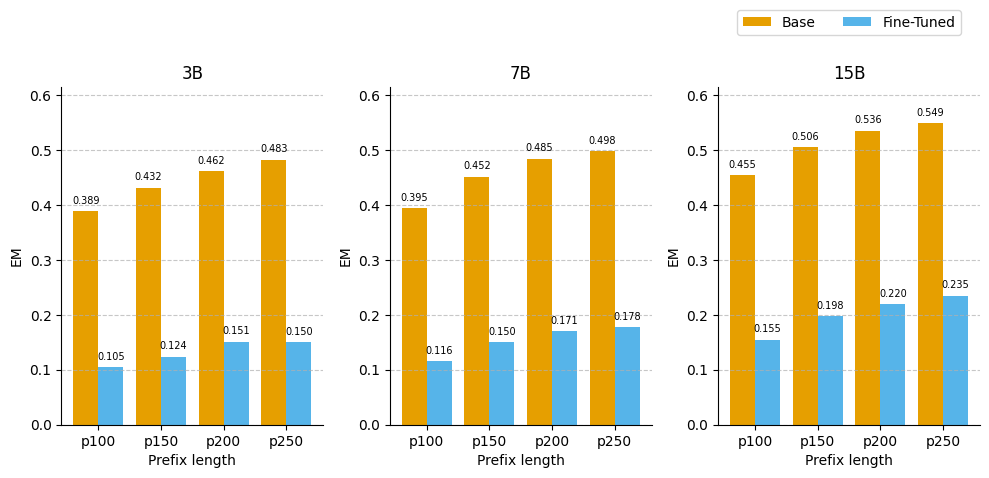

In [32]:
plt.rc("axes", prop_cycle=line_cycler)


fig, axes = plt.subplots(1, 3, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()

# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.8

# Define a color palette
labels = ['3B', '7B', '15B']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]
    
    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)
    
    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    positions_ep3 = bar_positions + width / 2  # center align ftune bars
    
    bars1 = ax.bar(positions_ep0, df_plen_ep0[label], width, label='Base')
    bars2 = ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned')
    
    # Add value labels on top of bars
    for j, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        height1 = bar1.get_height()
        height2 = bar2.get_height()
        
        # Add text labels showing exact EM scores
        ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.01,
                f'{height1:.3f}', ha='center', va='bottom', fontsize=7)
        ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.01,
                f'{height2:.3f}', ha='center', va='bottom', fontsize=7)
    
    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(f'{label}')
    
    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
    
    # Set the same y-axis limit with padding for labels
    ax.set_ylim(0, max_value * 1.12)  # Add 12% padding for labels
    
    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)
    
    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./attack_forget_plen.pdf', format='pdf')

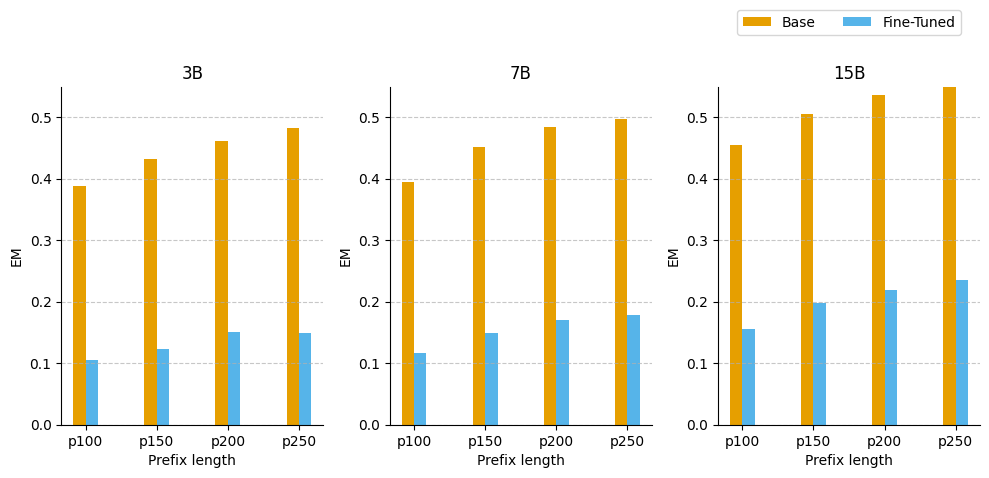

In [33]:
plt.rc("axes", prop_cycle=line_cycler)


fig, axes = plt.subplots(1, 3, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()

# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.35

# Define a color palette
labels = ['3B', '7B', '15B']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    positions_ep3 = bar_positions + width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_ep0[label], width, label='Base')
    ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./old-attack_forget_plen.pdf', format='pdf')

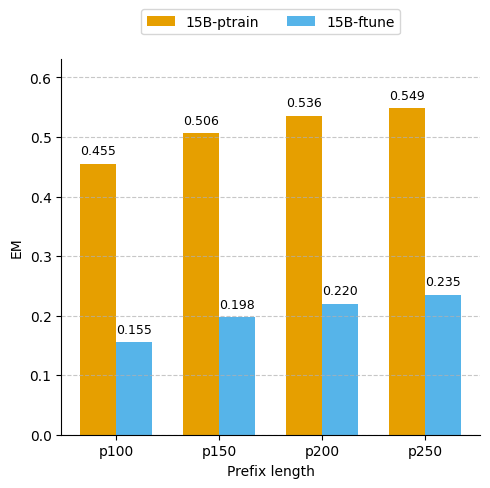

In [34]:
plt.rc("axes", prop_cycle=line_cycler)


# Only plot the last column
last_col = df_plen_ep0.columns[-1]
fig, axes = plt.subplots(1, 1, figsize=(5, 5))  # Single subplot for last column

bar_width = 0.35  # Width of each bar
bar_positions = np.arange(len(df_plen_ep0.index))  # x positions for bars

# Plotting
ax = axes
bars1 = ax.bar(bar_positions - bar_width / 2, df_plen_ep0[last_col], bar_width, label=f'{last_col}-ptrain')
bars2 = ax.bar(bar_positions + bar_width / 2, df_plen_ep3[last_col], bar_width, label=f'{last_col}-ftune')

# Add value labels on top of bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    # Get the height of each bar
    height1 = bar1.get_height()
    height2 = bar2.get_height()

    # Add text labels showing exact EM scores
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.01,
            f'{height1:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.01,
            f'{height2:.3f}', ha='center', va='bottom', fontsize=9)

# Hide spines
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Labels and ticks
ax.set_xlabel('Prefix length')
ax.set_ylabel('EM')
ax.set_xticks(bar_positions)
ax.set_xticklabels(df_plen_ep0.index)

# Legend and grid
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
# Adjust y-limit to accommodate labels
max_val = max(df_plen_ep0[last_col].max(), df_plen_ep3[last_col].max())
ax.set_ylim(0, max_val * 1.15)  # Add 15% padding for labels
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('./attack_forget_plen15.pdf', format='pdf')

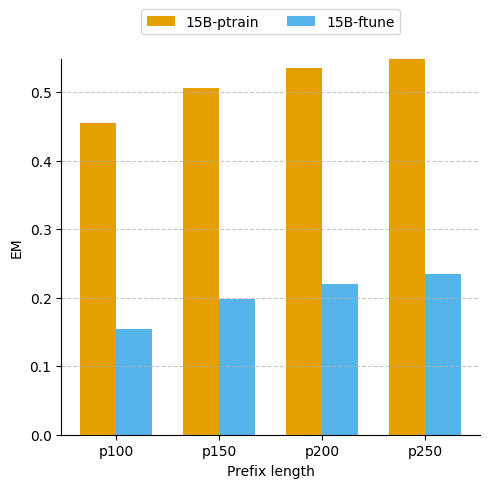

In [35]:
#plt.rc("axes", prop_cycle=line_cycler)


# Only plot the last column
last_col = df_plen_ep0.columns[-1]
fig, axes = plt.subplots(1, 1, figsize=(5, 5))  # Single subplot for last column

bar_width = 0.35  # Width of each bar
bar_positions = np.arange(len(df_plen_ep0.index))  # x positions for bars

# Plotting
ax = axes
ax.bar(bar_positions - bar_width / 2, df_plen_ep0[last_col], bar_width, label=f'{last_col}-ptrain')
ax.bar(bar_positions + bar_width / 2, df_plen_ep3[last_col], bar_width, label=f'{last_col}-ftune')

# Hide spines
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Labels and ticks
ax.set_xlabel('Prefix length')
ax.set_ylabel('EM')
ax.set_xticks(bar_positions)
ax.set_xticklabels(df_plen_ep0.index)

# Legend and grid
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
ax.set_ylim(0, max(df_plen_ep0[last_col].max(), df_plen_ep3[last_col].max()))
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('./old-attack_forget_plen15.pdf', format='pdf')

In [36]:
df_plen_ep3_base = pd.DataFrame({'3b': plen_3b_baseline['em'], '7b': plen_7b_baseline['em'], '15b': plen_15b_baseline['em']})
df_plen_ep3_base

,3b,7b,15b
p100,-0.284,-0.279,-0.300
p150,-0.308,-0.302,-0.308
p200,-0.311,-0.314,-0.316
p250,-0.333,-0.320,-0.314


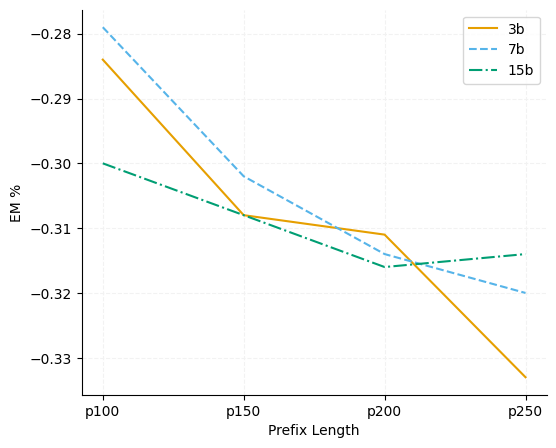

In [37]:
fig, ax = plt.subplots(figsize=(6, 5))
plt.rc("axes", prop_cycle=line_cycler)



# Define a nice color palette:
labels = ['3b', '7b', '15b']
markers = ['o', 'o', 'o']
#markers = ['s', 'P', 'o']
for i, label in enumerate(labels):
    # Line
    ax.plot(df_plen_ep3_base.index, df_plen_ep3_base[label], label=label , markeredgewidth=0.5, markersize=5) #color=colors[i],
    #ax.plot(df_plen_ep3_base.index, df_plen_ep3_base[label], label=label, marker=markers[i] ,color=colors[i])

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

# Only show ticks on the left and bottom spines
#ax.yaxis.set_ticks_position("left")
#ax.xaxis.set_ticks_position("bottom")

#ax.set_title('Data extraction attack through epochs')
ax.set_xlabel('Prefix Length')
ax.set_ylabel('EM %')
plt.legend(frameon=True)
plt.grid(axis='both', color='0.95', linestyle='--')




plt.show()
fig.savefig('./attack_forget_plen_line.pdf', format='pdf')

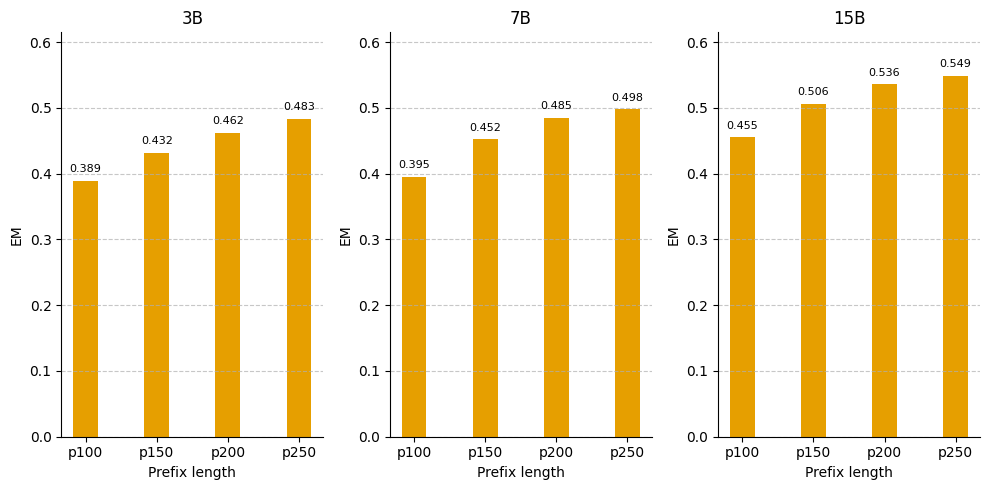

In [38]:
plt.rc("axes", prop_cycle=line_cycler)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()

# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.35

# Define a color palette
labels = ['3B', '7B', '15B']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]
    
    # Define width for each group
    width = bar_width #/ 2  # Since there are two groups for each label (ptrain and ftune)
    
    # Positions for the bars in this group
    positions_ep0 = bar_positions #- width / 2  # center align ptrain bars
    positions_ep3 = bar_positions #+ width / 2  # center align ftune bars
    
    bars = ax.bar(positions_ep0, df_plen_ep0[label], width, label=f'{label}')
    #ax.bar(positions_ep3, df_plen_ep3[label], width, label=f'{label}-ftune')
    
    # Add value labels on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(label)
    
    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, handlelength=0)
    # Set the same y-axis limit with padding for labels
    ax.set_ylim(0, max_value * 1.12)  # Add 12% padding for labels
    
    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)
    
    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('./attack_forget_plen_pre.pdf', format='pdf')

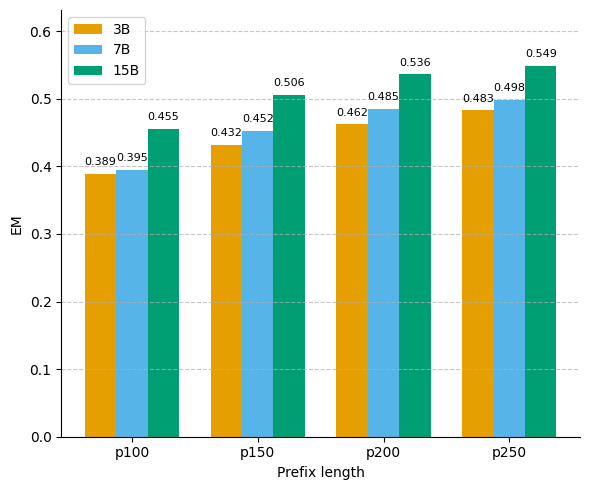

In [39]:
import numpy as np
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(6, 5))

labels = ['3B', '7B', '15B']
colors = ['#E69F00', '#56B4E9', '#009E73']

x = np.arange(len(df_plen_ep0.index))  # Prefix length positions
width = 0.25  # Width of bars

# Create bars for each model size
for i, (label, color) in enumerate(zip(labels, colors)):
    bars = ax.bar(x + i*width, df_plen_ep0[label], width, label=label, color=color)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Prefix length')
ax.set_ylabel('EM')
ax.set_xticks(x + width)  # Center the tick labels
ax.set_xticklabels(df_plen_ep0.index)

# Adjust y-limit to accommodate labels
max_val = df_plen_ep0[labels].max().max()
ax.set_ylim(0, max_val * 1.15)

# Create legend with rectangular patches
legend_elements = [Patch(facecolor='#E69F00', label='3B'),
                   Patch(facecolor='#56B4E9', label='7B'),
                   Patch(facecolor='#009E73', label='15B')]

plt.legend(handles=legend_elements, frameon=True, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('./attack_forget_plen_pre-all.pdf', format='pdf')

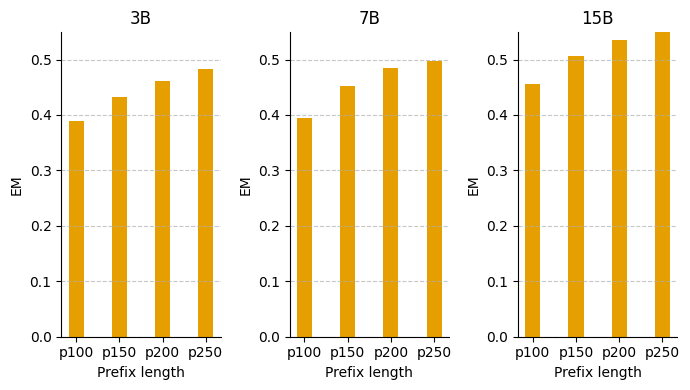

In [40]:
plt.rc("axes", prop_cycle=line_cycler)

fig, axes = plt.subplots(1, 3, figsize=(7, 4))  # Increased figure width
axes = axes.flatten()

# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.35

# Define a color palette
labels = ['3B', '7B', '15B']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width #/ 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions #- width / 2  # center align ptrain bars
    positions_ep3 = bar_positions #+ width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_ep0[label], width, label=f'{label}')
    #ax.bar(positions_ep3, df_plen_ep3[label], width, label=f'{label}-ftune')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(label)

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, handlelength=0)
    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('./old-attack_forget_plen_pre.pdf', format='pdf')